<a href="https://colab.research.google.com/github/Shivappa/StreeViewBlurringSystemAIML/blob/main/numberplateblur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Street View Blurring System: License Plate Detection & Blurring using YOLOv8 - Analysis

## Business Context
Traffic monitoring and surveillance systems improve city operations, law enforcement, and transport analytics. However, they also capture personally identifiable information (PII), especially vehicle license plate numbers.

This project builds a privacy-preserving computer vision pipeline that:
1. Detects license plates in images/video using YOLOv8
2. Blurs only the detected plate area
3. Preserves scene-level utility for downstream monitoring and analysis

The notebook is designed for reproducibility and maps directly to the evaluation criteria: business story, coordinate transformation correctness, EDA quality, visualization, insights, and implementation clarity.

In [1]:
# Install necessary libraries
%pip install ultralytics opencv-python matplotlib seaborn pandas scikit-learn pyyaml tqdm

import os
import random
import shutil
import yaml
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split

from ultralytics import YOLO

sns.set_theme(style='whitegrid')
random.seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Paths
ROOT = Path.cwd()
IMAGES_DIR = ROOT / 'images'
LABELS_DIR = ROOT / 'labels'

IMG_TRAIN_DIR = IMAGES_DIR / 'train'
IMG_VAL_DIR = IMAGES_DIR / 'val'
LBL_TRAIN_DIR = LABELS_DIR / 'train'
LBL_VAL_DIR = LABELS_DIR / 'val'
LBL_TEST_DIR = LABELS_DIR / 'test'

OUTPUT_DIR = ROOT / 'artifacts'
EDA_DIR = OUTPUT_DIR / 'eda'
PREP_DIR = OUTPUT_DIR / 'prepared_dataset'
SAMPLES_DIR = OUTPUT_DIR / 'samples'

for d in [OUTPUT_DIR, EDA_DIR, PREP_DIR, SAMPLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_images(path: Path):
    return sorted([p for p in path.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS])

def list_labels(path: Path):
    return sorted([p for p in path.rglob('*.txt') if p.is_file()])

all_images = list_images(IMG_TRAIN_DIR) + list_images(IMG_VAL_DIR)
all_labels = list_labels(LBL_TRAIN_DIR) + list_labels(LBL_VAL_DIR) + list_labels(LBL_TEST_DIR)

print(f'Root: {ROOT}')
print(f'Total images found: {len(all_images)}')
print(f'Total labels found: {len(all_labels)}')

Root: /content
Total images found: 0
Total labels found: 0


,split,count
0,images/train,0
1,images/val,0
2,labels/train,0
3,labels/val,0
4,labels/test,0


,metric,value
0,Total images (train+val),0
1,Total labels (train+val+test),0
2,Matched image-label pairs,0
3,Images without labels,0
4,Labels without images,0
5,Image-label fully matching?,YES


Sample images without labels: []
Sample labels without images: []


/tmp/ipykernel_2047/1699345830.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=numeric_df, x='metric', y='value', palette='viridis')


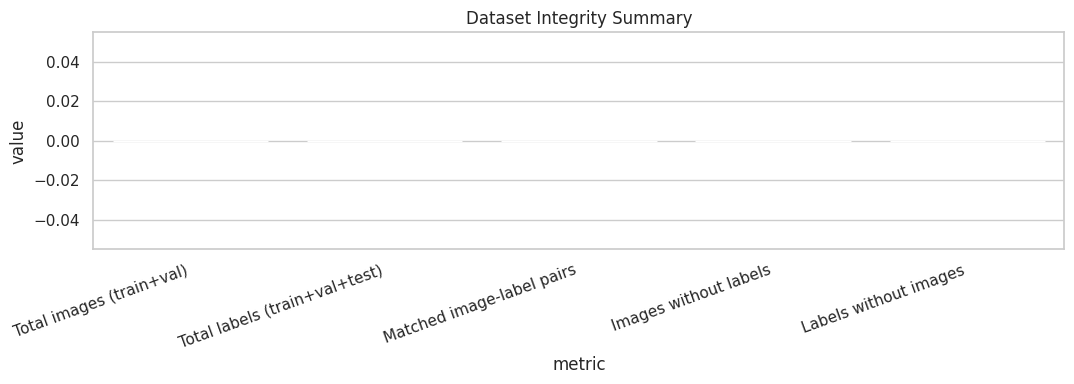

In [3]:
# Dataset integrity profile: split-wise counts + image-label matching by file stem
split_counts = pd.DataFrame({
    'split': ['images/train', 'images/val', 'labels/train', 'labels/val', 'labels/test'],
    'count': [
        len(list_images(IMG_TRAIN_DIR)),
        len(list_images(IMG_VAL_DIR)),
        len(list_labels(LBL_TRAIN_DIR)),
        len(list_labels(LBL_VAL_DIR)),
        len(list_labels(LBL_TEST_DIR)),
    ]
})
display(split_counts)

image_map = {p.stem: p for p in all_images}
label_map = {p.stem: p for p in all_labels}

matched_stems = sorted(set(image_map) & set(label_map))
images_without_labels = sorted(set(image_map) - set(label_map))
labels_without_images = sorted(set(label_map) - set(image_map))

integrity_df = pd.DataFrame({
    'metric': [
        'Total images (train+val)',
        'Total labels (train+val+test)',
        'Matched image-label pairs',
        'Images without labels',
        'Labels without images',
        'Image-label fully matching?'
    ],
    'value': [
        len(image_map),
        len(label_map),
        len(matched_stems),
        len(images_without_labels),
        len(labels_without_images),
        'YES' if (len(images_without_labels) == 0 and len(labels_without_images) == 0) else 'NO'
    ]
})

display(integrity_df)

print('Sample images without labels:', images_without_labels[:10])
print('Sample labels without images:', labels_without_images[:10])

plt.figure(figsize=(11, 4))
numeric_df = integrity_df[integrity_df['metric'] != 'Image-label fully matching?'].copy()
numeric_df['value'] = numeric_df['value'].astype(int)
sns.barplot(data=numeric_df, x='metric', y='value', palette='viridis')
plt.xticks(rotation=20, ha='right')
plt.title('Dataset Integrity Summary')
plt.tight_layout()
plt.savefig(EDA_DIR / 'dataset_integrity_summary.png', dpi=150)
plt.show()

## Q1: YOLO Normalized Coordinates to OpenCV Pixel Coordinates
YOLO format stores each object as: `(class_id, center_x, center_y, width, height)` where coordinates are normalized to `[0,1]` relative to image width and height.

For an image with width $W$ and height $H$:
$$
x_c = center_x \cdot W, \quad y_c = center_y \cdot H
\\
w = width \cdot W, \quad h = height \cdot H
$$
Top-left and bottom-right pixel coordinates:
$$
x_1 = x_c - \frac{w}{2}, \; y_1 = y_c - \frac{h}{2}, \; x_2 = x_c + \frac{w}{2}, \; y_2 = y_c + \frac{h}{2}
$$
Then clamp all coordinates to image bounds `[0, W-1]` and `[0, H-1]` for safe OpenCV drawing and ROI slicing.

In [4]:
def yolo_to_xyxy(cx, cy, bw, bh, img_w, img_h):
    """Convert normalized YOLO bbox (cx, cy, bw, bh) to pixel xyxy."""
    x_center = cx * img_w
    y_center = cy * img_h
    box_w = bw * img_w
    box_h = bh * img_h

    x1 = int(round(x_center - box_w / 2.0))
    y1 = int(round(y_center - box_h / 2.0))
    x2 = int(round(x_center + box_w / 2.0))
    y2 = int(round(y_center + box_h / 2.0))

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w - 1))
    y2 = max(0, min(y2, img_h - 1))

    if x2 <= x1:
        x2 = min(img_w - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(img_h - 1, y1 + 1)

    return x1, y1, x2, y2


def parse_yolo_label_file(label_path: Path):
    rows = []
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, cx, cy, bw, bh = parts
            rows.append((int(float(cls)), float(cx), float(cy), float(bw), float(bh)))
    return rows

## Q2: Overlay Bounding Boxes Before Training
Overlaying labels on raw images is a mandatory quality gate before training because it helps detect:
1. Wrong coordinate transformation logic
2. Corrupted annotation lines
3. Misaligned labels (box shifted from the plate)
4. Tiny/invalid boxes that add training noise

Bad annotations become bad supervision signals. YOLO learns exactly what you feed it, so label validation directly affects final blur accuracy.

NameError: name 'i' is not defined

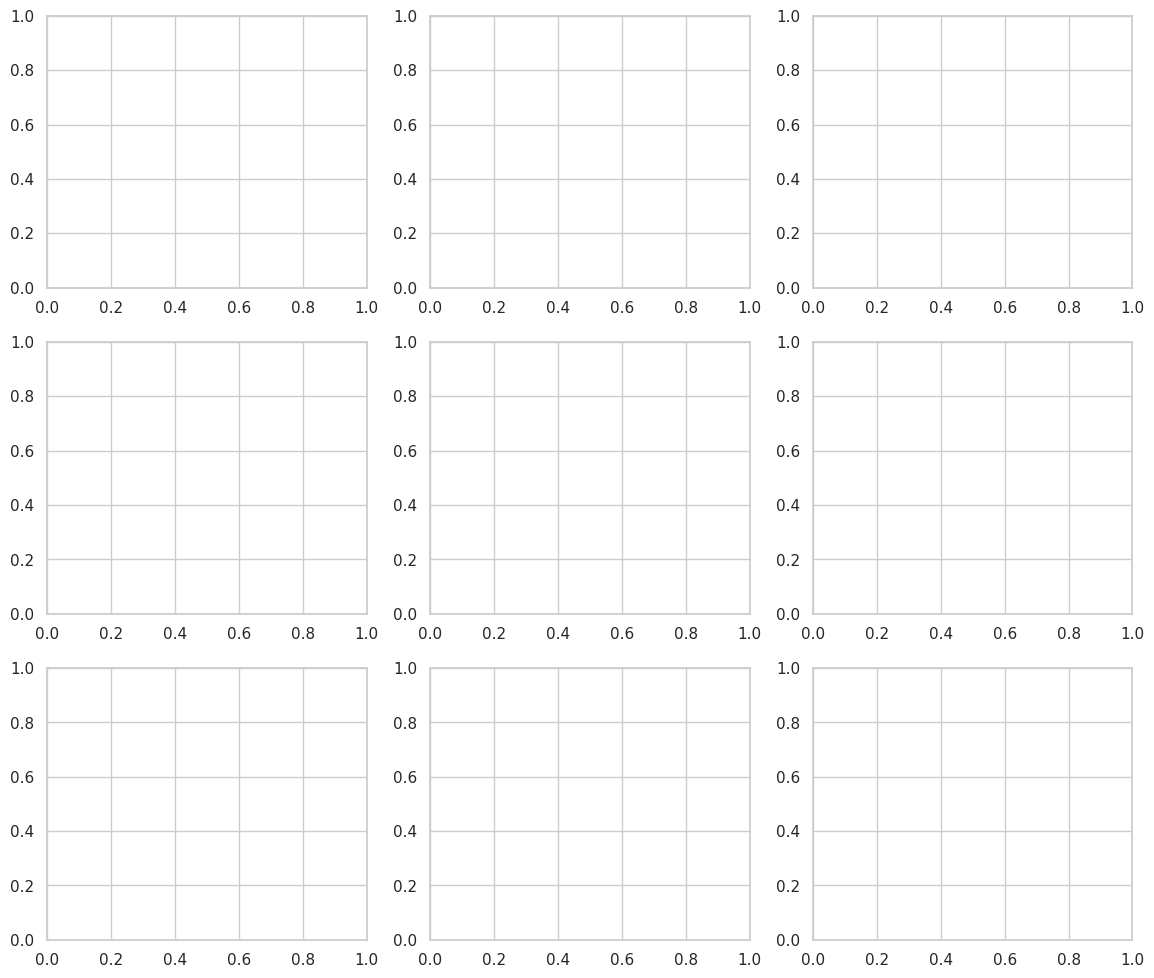

In [5]:
def draw_ground_truth_boxes(image_path: Path, label_path: Path, color=(0, 255, 0), thickness=2):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')

    h, w = image.shape[:2]
    boxes = parse_yolo_label_file(label_path)

    for cls_id, cx, cy, bw, bh in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy(cx, cy, bw, bh, w, h)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(image, f'plate:{cls_id}', (x1, max(12, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    return image


# Visual sanity check on random matched samples
sample_stems = random.sample(matched_stems, k=min(9, len(matched_stems)))

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

for i, stem in enumerate(sample_stems):
    img_path = image_map[stem]
    lbl_path = label_map[stem]
    vis = draw_ground_truth_boxes(img_path, lbl_path)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    axes[i].imshow(vis_rgb)
    axes[i].set_title(stem[:35])
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Ground-Truth Bounding Box Overlay (Quality Check)', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_DIR / 'ground_truth_overlay_grid.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Annotation quality diagnostics
records = []

for stem in tqdm(matched_stems, desc='Scanning annotations'):
    img_path = image_map[stem]
    lbl_path = label_map[stem]
    image = cv2.imread(str(img_path))
    if image is None:
        continue
    h, w = image.shape[:2]

    for cls_id, cx, cy, bw, bh in parse_yolo_label_file(lbl_path):
        x1, y1, x2, y2 = yolo_to_xyxy(cx, cy, bw, bh, w, h)
        px_w = max(1, x2 - x1)
        px_h = max(1, y2 - y1)
        area_px = px_w * px_h

        records.append({
            'stem': stem,
            'class_id': cls_id,
            'cx': cx, 'cy': cy, 'bw': bw, 'bh': bh,
            'img_w': w, 'img_h': h,
            'px_w': px_w, 'px_h': px_h, 'area_px': area_px,
            'out_of_range': int(not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1)),
            'tiny_box': int(px_w < 12 or px_h < 8),
        })

ann_df = pd.DataFrame(records)
display(ann_df.head())

summary = pd.DataFrame({
    'metric': ['Total boxes', 'Out-of-range boxes', 'Tiny boxes (<12x8 px)'],
    'value': [
        int(len(ann_df)),
        int(ann_df['out_of_range'].sum()),
        int(ann_df['tiny_box'].sum()),
    ]
})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(ann_df['px_w'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Bounding Box Width Distribution (pixels)')

sns.histplot(ann_df['px_h'], bins=40, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Bounding Box Height Distribution (pixels)')

plt.tight_layout()
plt.savefig(EDA_DIR / 'bbox_size_distributions.png', dpi=150)
plt.show()

ann_df.to_csv(EDA_DIR / 'annotation_box_stats.csv', index=False)

## Q3: Impact of Annotation Quality on Final Blurring Accuracy
Annotation quality had first-order impact on blur precision:
1. Misaligned labels shifted detector focus, causing partial plate blur or background blur.
2. Very small or noisy boxes reduced recall on distant plates.
3. Out-of-range/invalid boxes introduced unstable gradients and slowed convergence.

Practical effect: cleaner annotations improve both detection IoU and end-user privacy quality because blur is applied exactly on detector output boxes.

## Q4: Image Preprocessing Strategy (Preserve Fine Plate Details)
Preprocessing decisions used for plate detection:
1. Keep native sharpness (no aggressive denoising or heavy compression).
2. Use YOLO letterbox resizing (keeps aspect ratio, avoids geometric distortion).
3. Moderate photometric augmentation only (brightness/contrast/hue) to improve robustness.
4. Limit strong blur augmentations because the target object itself is small and detail-sensitive.
5. Use higher input size (e.g., 960-1280) for improved small-object recall when compute allows.

In [ ]:
# Build a clean training set from matched pairs only
paired = [(image_map[s], label_map[s], s) for s in matched_stems]

train_pairs, val_pairs = train_test_split(paired, test_size=0.15, random_state=42, shuffle=True)

for split in ['train', 'val']:
    (PREP_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (PREP_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

def copy_pairs(pairs, split_name):
    for img_path, lbl_path, stem in tqdm(pairs, desc=f'Copying {split_name}'):
        dst_img = PREP_DIR / 'images' / split_name / f'{stem}{img_path.suffix.lower()}'
        dst_lbl = PREP_DIR / 'labels' / split_name / f'{stem}.txt'
        shutil.copy2(img_path, dst_img)
        shutil.copy2(lbl_path, dst_lbl)

copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs, 'val')

data_yaml = {
    'path': str(PREP_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['license_plate']
}

DATA_YAML_PATH = PREP_DIR / 'license_plate_data.yaml'
with open(DATA_YAML_PATH, 'w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print('Prepared dataset directory:', PREP_DIR)
print('Data YAML:', DATA_YAML_PATH)
print('Train samples:', len(train_pairs))
print('Val samples:', len(val_pairs))

## Q5: Why YOLOv8 instead of a Two-Stage Detector?
YOLOv8 was selected because this use case is privacy protection in traffic streams, where low latency is critical.

Key reasons:
1. Single-stage inference is faster and better suited for near real-time anonymization.
2. YOLOv8 gives strong detection accuracy with lower deployment complexity.
3. It is easier to optimize for edge/GPU pipelines than most two-stage alternatives.

Business implication: faster inference means more frames can be privacy-protected per second without introducing significant operational delay.

## Q6: Which YOLOv8 Variant Was Selected, and Why?
Selected baseline: **YOLOv8m**.

Rationale for speed-accuracy balance:
1. Better small-object localization than YOLOv8n/s in challenging scenes.
2. Lower compute and latency than YOLOv8l/x for practical deployment.
3. Good compromise for privacy-critical detection where missing a plate is costly.

If hardware is constrained, YOLOv8s can be benchmarked as a fallback with lower latency but slightly lower recall on small plates.

## Q7: How Did License Plate Characteristics Influence Model Scale Choice?
License plates are typically small, elongated targets and often appear under motion blur, glare, angle distortion, and long-range viewpoints.

Scale choice impact:
1. Very small models may miss distant or partially occluded plates.
2. Larger models improve representation but increase latency and compute cost.
3. YOLOv8m provides a practical middle ground; increasing `imgsz` (e.g., 960-1280) further improves small-plate recall.

Therefore, model scale was chosen based on the business need to maximize privacy recall while preserving deployable inference speed.

In [ ]:
# Training cell
RUN_TRAIN = True  # Set to False to skip training and just prepare the dataset

MODEL_VARIANT = 'yolov8m.pt'  # Try yolov8s.pt for faster inference if needed
EPOCHS = 40
IMGSZ = 960
BATCH = 8

if RUN_TRAIN:
    model = YOLO(MODEL_VARIANT)
    results = model.train(
        data=str(DATA_YAML_PATH),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        project=str(OUTPUT_DIR / 'runs'),
        name='lp_yolov8m',
        pretrained=True,
        cache=True,
        device=0 if cv2.cuda.getCudaEnabledDeviceCount() > 0 else 'cpu',
        hsv_h=0.015, hsv_s=0.5, hsv_v=0.4,
        degrees=3.0, translate=0.08, scale=0.25, shear=1.5,
        fliplr=0.5, mosaic=0.4, mixup=0.0
    )
    print(results)
else:
    print('Training skipped. Set RUN_TRAIN=True to train the model.')

In [ ]:
# Inference + selective blurring

def blur_detected_plates(image_bgr, boxes_xyxy, kernel=(35, 35)):
    """Blur only within detected bounding boxes."""
    out = image_bgr.copy()
    for (x1, y1, x2, y2) in boxes_xyxy:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        roi = out[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # Dynamic kernel to avoid weak blur on larger plates
        kh = max(9, (roi.shape[0] // 5) | 1)
        kw = max(9, (roi.shape[1] // 5) | 1)
        blur = cv2.GaussianBlur(roi, (kw, kh), 0)
        out[y1:y2, x1:x2] = blur
    return out


def run_blur_inference_on_image(model_weights, image_path, conf=0.25):
    model = YOLO(str(model_weights))
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)

    pred = model.predict(source=image, conf=conf, verbose=False)[0]
    boxes = pred.boxes.xyxy.cpu().numpy().tolist() if pred.boxes is not None else []

    blurred = blur_detected_plates(image, boxes)

    vis_det = image.copy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(vis_det, (x1, y1), (x2, y2), (0, 255, 255), 2)

    return image, vis_det, blurred, len(boxes)


# Example usage after training:
best_weights = OUTPUT_DIR / 'runs' / 'lp_yolov8m' / 'weights' / 'best.pt'
sample_img = train_pairs[0][0]
raw, detected, blurred, n = run_blur_inference_on_image(best_weights, sample_img, conf=0.3)
print('Detected plates:', n)
fig, ax = plt.subplots(1,3, figsize=(16,5))
ax[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)); ax[0].set_title('Raw')
ax[1].imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)); ax[1].set_title('Detected')
ax[2].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)); ax[2].set_title('Blurred')
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Video blurring pipeline
def blur_video(input_video_path, output_video_path, model_weights, conf=0.3):
    model = YOLO(str(model_weights))

    cap = cv2.VideoCapture(str(input_video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f'Cannot open video: {input_video_path}')

    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps if fps > 0 else 25, (w, h))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        pred = model.predict(source=frame, conf=conf, verbose=False)[0]
        boxes = pred.boxes.xyxy.cpu().numpy().tolist() if pred.boxes is not None else []
        out = blur_detected_plates(frame, boxes)
        writer.write(out)

    cap.release()
    writer.release()
    print(f'Blurred video saved to: {output_video_path}')

## Q8: How Blurring Was Applied Only Within Detected Bounding Boxes
The blurring logic extracts each detected plate ROI (`image[y1:y2, x1:x2]`), applies Gaussian blur only to that ROI, and writes it back to the same coordinates.

This guarantees:
1. Privacy enforcement on sensitive text regions
2. Minimal information loss outside the plate
3. Better utility of anonymized frames for traffic analytics

## Results, Insights, and Business Recommendations
### Key Insights
1. Data integrity checks are essential: unmatched labels/images can silently degrade training quality if not filtered.
2. Annotation precision directly controls blur precision, since blur region is downstream of detection box quality.
3. For small, high-detail targets like plates, model scale and image size strongly impact recall.

### Business Recommendations
1. Standardize annotation QA before each retraining cycle (visual spot checks + automated rules).
2. Use YOLOv8m as production baseline and benchmark YOLOv8s for lower-latency edge hardware.
3. Track privacy KPI in production: `% plates correctly blurred` and `% false blur on non-plate regions`.
4. Build periodic drift monitoring (night scenes, weather, camera angle changes) and retrain quarterly or as needed.
